# Parte V - Análisis Causal

Hasta ahora hemos usado el modelo de regresión para estudiar la relación entre una variable dependiente $y$ (*outcome*) y una o múltiples variables independientes $x$ (covariables o *covariates*). Sin embargo, **correlación no implica causalidad**.

En economía, y muchas otras disciplinas, queremos establecer relaciones causales. Es decir, nos interesa responder la pregunta **¿cuál es el efecto o impacto de $x$ en $y$?**

En el de modelo de regresión, el supuesto clave para interpretar nuestras estimaciones como efectos causales es:

$$E(\varepsilon | x) = 0$$

Por lo tanto, tratar de argumentar la validez de este supuesto concentrará nuestra atención.

## 5.1 Modelo de Resultados Potenciales

Iniciamos nuestro estudio acerca de la causalidad entre variables con el modelo de resultados potenciales de Rubin. 

Suponga que nos interesa determinar el efecto causal de un tratamiento o política sobre una variable $y$. Definimos la variable $D_i$ como un indicador que toma el valor de 1 si el individuo $i$ recibió el tratamiento y 0 en caso contrario. Es decir, $D_i$ nos permite identificar los individuos tratados y los no tratados.

**En un mundo ideal** quisieramos observar el cambio (o **efecto**) en la variable $y_i$ en presencia de tratamiento ($D_i = 1$) y ausencia de tratamiento ($D_i = 0$). Es decir, el efecto del tratamiento para cada individuo $i$ es:

$$\tau_i = y_i(1) - y_i(0)$$

donde $y_i(1)$ es el valor que toma la variable de interés cuando $i$ es tratado y $y_i(0)$ es el valor que toma cuando $i$ no es tratado.

### 5.1.1 Problema de Análisis Causal (*Observability Problem*)

Es evidente que no podemos observar $y_i(1)$ y $y_i(0)$ al mismo tiempo. 

**Para cada individuo solo observamos un valor $y_i$**, es decir, solo observamos $y_i(1)$ para los individuos tratados y solo observamos $y_i(0)$ para los individuos no tratados. Esto lo podemos resumir de la siguiente manera:

\begin{equation*}
y_i = y_i(1) \cdot D_i + y_i(0) \cdot (1 - D_i) =
    \left\{\begin{array}{lr}
    y_i(1), & \text{si } D_i = 1 \\
    y_i(0), & \text{si } D_i = 0 \\
    \end{array}\right.
\end{equation*}

Note que podemos reescribir $y_i$ cómo una función de regresión:

$$y_i = \underbrace{\hspace{3pt}\alpha\hspace{3pt}}_{E(y_i(0))} + \underbrace{\hspace{2pt}\tau_i\hspace{2pt}}_{y_i(1) - y_i(0)} D_i + \underbrace{\hspace{2pt}\varepsilon_i\hspace{2pt}}_{y_i(0) - E(y_i(0))}$$

### 5.1.2 Parámetros de Interés

Debido a que no podemos determinar el efecto del tratamiento para cada individuo **nos concentraremos en el efecto promedio para una población** de estudio. Los siguientes son parámetros de interés que nos interesa considerar:

- **Efecto Promedio** (*ATE: Average Treatment Effect*): Relevante para programas universales

$$E(\tau_i) = E(y_i(1) - y_i(0)) = E(y_i(1)) - E(y_i(0))$$

- **Efecto Promedio en Tratados** (*ATT: Average Treatment on Treated*): Relevante para estimar la efectividad de una política (programa o tratamiento)

$$E(\tau_i | D_i = 1) = E(y_i(1)| D_i = 1) - \underbrace{E(y_i(0) | D_i = 1)}_{\text{Contrafactual}}$$

- **Efecto Promedio en No Tratados** (*ATU: Average Treatment on Untreated*): Relevate para estimar como una política puede afectar poblaciones no focalizadas (*spillovers*)

$$E(\tau_i | D_i = 0) = \underbrace{E(y_i(1)| D_i = 0)}_{\text{Contrafactual}} - E(y_i(0) | D_i = 0)$$

Es importante observar que el promedio contrafactual es un resultado hipotetico, pues no lo podemos observar.

### 5.1.3 Modelo Regresión y Análisis Causal 

Supongamos por ahora que el efecto del programa es igual para todos los individuos, es decir, suponga que: 

$$\tau_i = \tau$$

De esta manera, nuestro modelo de regresión está dado por:

$$y_i = \alpha + \tau D_i + \varepsilon_i$$

Observe que 

$$E(y_i(1) | D_i = 1) = \alpha + \tau + E(\varepsilon_i | D_i = 1)$$
$$E(y_i(0) | D_i = 0) = \alpha + E(\varepsilon_i | D_i = 0)$$ 


### 5.1.4 Sesgo de Autoselección 

A partir de esta ecuaciones podemos determinar que:

\begin{align*}
    \tau & = E(y_i(1) | D_i = 1) - E(y_i(0) | D_i = 0) + E(\varepsilon_i | D_i = 1) - E(\varepsilon_i | D_i = 0) \\\\
     & = E(y_i(1) | D_i = 1) - E(y_i(0) | D_i = 0) + \underbrace{E(y_i(0) | D_i = 1) - E(y_i(0) | D_i = 0)}_{\text{Sesgo de Autoselección}} \\
     & = ATT + \text{Sesgo de Autoselección} \\
\end{align*}

Observe que si $E(\varepsilon_i|D_i) = 0$, entonces

$$\tau = ATT = E(y_i(1) | D_i = 1) - E(y_i(0) | D_i = 0)$$

### 5.1.5 Asignación Aleatoria a Tratamiento (RCT)

Asignar aleatoriamente el tratamiento implica que los factores observables y no observables que componen el término de error $\varepsilon_i$ son independiente de $D_i$. En otras palabras, 

$$E(\varepsilon_i | D_i) = E(\varepsilon_i) = 0$$

Si la asignación a tratamiento es aleatoria $D_i$ también es independiente de los resultados potenciales. Es decir, 

\begin{align*}
E(y_i | D_i = 1) - E(y_i | D_i = 0) & = E(y_i(1) | D_i = 1) - E(y_i(0) | D_i = 0) \\\\
& = E(y_i(1) | D_i = 1) - E(y_i(0) | {\color{red} D_i = 1}) \\\\
& = E(y_i(1) - y_i(0) | {\color{red} D_i = 1})\\\\
& = E(y_i(1) - y_i(0))\\
\end{align*}




## 5.2 Variables Instrumentales

Suponga que estamos interesados en estudiar el efecto causal que tiene la variable $x$ sobre la variable de resultado $y$. Para determinar esta relación causal usted cuenta con información para $n$ individuos y quiere estimar la siguiente ecuación de regresión:

$$y_i = \beta_0 + \beta_1 x_i + \varepsilon_i$$

Usted estima esta regresión a través de MCO. Sin embargo, usted sospecha que el supuesto de exogeneidad no se cumple, es decir:

$$E(\varepsilon_i | x_i) \neq 0 \quad \Rightarrow \quad E(\hat\beta) \neq \beta$$

Múltiples razones pueden sugerir que el supuesto de exogenidad se viola. Algunas de ellas son:

1. **Omitir variables relevantes**: factores (observables y no observables) que explican $y_i$ y que se relaciona de manera importante con $x_i$.
2. **Error de medición**: si en lugar de observar $x_i$ solo podemos observar $x_i^* = x_i + \xi_i$
3. **Simultaneidad o causalidad inversa**: Si $x_i$ afecta $y_i$ y $y_i$ afecta $x_i$

### 5.2.1 Relevancia y Exogenidad de un Instrumento

El método de **variables instrumentales** (IV) es ampliamente usado por analístas e investigadores para estimar el efecto causal de $x_i$ en $y_i$. Es decir, a través de esta estrategia podemos obtener **estimadores consistentes**.

El uso de este método requiere de una variable $z_i$ o **instrumento** que cumple dos propiedades importantes:

1. **Relevancia** : El instrumento $z_i$ debe está fuertemente correlacionado con la variable endogena $x_i$. Es decir,

$$Cov(x_i, z_i) \neq 0$$

2. **Exogeneidad ó Restricción de Exclusión**: El instrumento $z_i$ debe ser cuasi-aletorio (*as good as random*) y solo debe afectar a $y_i$ a través de $x_i$. Es decir,

$$Cov(\varepsilon_i, z_i) = 0 \quad \Rightarrow \quad \beta_1 = \frac{Cov(y_i, z_i)}{Cov(x_i, z_i)}$$

Cabe mencionar que la primera condición se puede probar de manera empírica. Sin embargo, para la segunda condición no existe una prueba formal que nos permita determinar si el instrumento es cuasi-aleatorio.

### 5.2.2 Aplicaciones

- **Angrist (1990 AER)**: Este documento estudia las consecuencias de haber prestado servicio militar en la guerra de Vietnam sobre los ingresos laborales. 

    $y_i$ son ingresos, $x_i$ es el estatus de veterano, $z_i$ es la elegibilidad para servir en la guerra a partir de una lotería.
 

- **Angrist y Krueger (1991 QJE)**: Estudian el efecto de la educación sobre los salarios. En Estados Unidos y muchos otros paises, los estudiantes solo pueden ingresar al primer grado del sistema educativo a partir de cierta edad (5 años al 1 de Sep). Además, es obligatorio que los estudiantes estén hasta los 16 años en el sistema educativo. 
    
    $y_i$ son salarios, $x_i$ los años de educación completa, $z_i$ es el trimestre de nacimiento (1 = Ene-Ago, 0 = Sep-Dic). Observe que si $z_i = 1$, el individuo es obligado a completar mas años educativos antes de poder desertar.


- **Angrist, Graddy, e Imbens (2000 RESTUD)**: Estiman una función de demanda a partir de precios y cantidades vendidas de un producto. Sin embargo, estimar la función de demanda usando esta información tiene problemas de causalidad inversa. Observe que los precios están determinados por la demanda y la oferta al mismo tiempo. 

    $y_i$ son cantidades de merluza fresca en el Fulton Fish Market, $x_i$ es el precio, $z_i$ es una variable de condiciones climáticas en el mar (viento o temperatura) que afectan la oferta en el mercado.

### 5.2.3 Mínimos Cuadrados en Dos Etapas (MC2)

Para estimar el modelo de variables instrumentales se realiza un proceso secuencial. Recuerde que nos interesa estimar el efecto causal de la variable $x_i$ en $y_i$ a partir de la siguiente función de regresión:

$$y_i = \beta_0 + \beta_1 x_i + \varepsilon_i$$

Para ello procedemos en dos etapas:

- **Primera Etapa**: estimar $x_i$ usando la variable instrumental $z_i$. Si $Cov(z_i, \varepsilon_i) = 0$, entonces $\hat x_i$ contiene variacion que no esta relacionada con $\varepsilon_i$.

$$x_i = \pi_0 + \pi_1 z_i + u_i$$

- **Segunda Etapa**: estimar $y_i$ usando los valores predichos $\hat x_i$. 

$$y_i = \alpha + \beta \hat x_i + \eta_i$$

Observe que el estimador de $\beta$ se puede escribir como:

$$\hat\beta_{IV} = \frac{\sum_i^n(y_i - \bar y)(\hat x_i - \bar{\hat x})}{\sum_i^n(\hat x_i - \bar{\hat x})^2}$$

Note ademas que 

$$\hat x_i - \bar{\hat x} = \hat\pi_1 (z_i - \bar z)$$
 
Entonces 

$$\hat\beta_{IV} = \frac{\sum_i^n(y_i - \bar y)\hat\pi_1 (z_i - \bar z)}{\sum_i^n\hat\pi_1^2 (z_i - \bar z)^2} = \frac{1}{\hat\pi_1} \frac{\sum_i^n(y_i - \bar y)(z_i - \bar z)}{\sum_i^n(z_i - \bar z)^2} = \frac{\sum_i^n(z_i - \bar z)^2}{\sum_i^n (x_i - \bar x) (z_i - \bar z)} \frac{\sum_i^n(y_i - \bar y)(z_i - \bar z)}{\sum_i^n(z_i - \bar z)^2}$$

Finalmente, el estimador de $\beta_1$ en 2 etapas esta dado por:

$$\hat\beta_{IV} = \frac{\sum_i^n(y_i - \bar y)(z_i - \bar z)}{\sum_i^n (x_i - \bar x) (z_i - \bar z)} = \frac{\hat Cov(y_i, z_i)}{\hat Cov(x_i, z_i)}$$

### 5.2.4 Propiedades Estadisticas de $\hat\beta_{IV}$

\begin{align*}
E(\hat\beta_{IV}) & = E\left(\frac{\sum_i^n(y_i - \bar y)(z_i - \bar z)}{\sum_i^n (x_i - \bar x) (z_i - \bar z)}\right) \\
& =  E\left(\frac{\sum_i^n [(\beta_0 + \beta_1 x_i + \varepsilon_i) - (\beta_0 + \beta_1 \bar x + \bar \varepsilon)] (z_i - \bar z)}{\sum_i^n (x_i - \bar x) (z_i - \bar z)}\right) \\
& =  E\left(\frac{\sum_i^n [(\beta_1 (x_i - \bar x) + (\varepsilon_i - \bar \varepsilon)] (z_i - \bar z)}{\sum_i^n (x_i - \bar x) (z_i - \bar z)}\right) \\
& =  E\left(\frac{\beta_1 \sum_i^n (x_i - \bar x)(z_i - \bar z) + \sum_i^n (\varepsilon_i - \bar \varepsilon) (z_i - \bar z)}{\sum_i^n (x_i - \bar x) (z_i - \bar z)}\right) \\
& = \beta_1 +  E\left(\frac{\sum_i^n \varepsilon_i (z_i - \bar z)}{\sum_i^n (x_i - \bar x) (z_i - \bar z)}\right)
\end{align*}

Observe que la condicion de exogeniedad del instrumento implica que $Cov(\varepsilon_i, z_i) = 0$, pero no implica que $E(\varepsilon_i | z_i, x_i) = 0$. Entonces,

$$E\left(\frac{\sum_i^n \varepsilon_i (z_i - \bar z)}{\sum_i^n (x_i - \bar x) (z_i - \bar z)}\right) = E\left(\frac{\sum_i^n E(\varepsilon_i | z_i, x_i) (z_i - \bar z)}{\sum_i^n (x_i - \bar x) (z_i - \bar z)}\right) \neq 0$$

Es decir, el estimador de minimos cuadrados en dos etapas es sesgado

$$E(\hat\beta_{IV}) \neq \beta$$

Sin embargo, el estimador es consistente:

$$\hat\beta_{IV} = \frac{\hat Cov(y_i, z_i)}{\hat Cov(x_i, z_i)} \overset{p}{\to}  \frac{Cov(y_i, z_i)}{Cov(x_i, z_i)} = \beta_1$$

Se puede demostrar que

$$\hat\beta_{IV} \overset{d}{\to} N(\beta, \sigma^2_{\beta_{IV}}) \quad \text{ donde } \quad \sigma^2_{\beta_{IV}} = \frac{1}{n}\frac{V \left((z_i - \mu_z) \varepsilon_i\right)}{\left(Cov(x_i, z_i)\right)^2}$$
La varianza de $\hat\beta_{IV}$ se puede estimar a partir de la estimacion de la varianza y covarianza de los términos que aparecen en la expresión anterior:

$$se(\hat\beta_{IV}) = \sqrt{\frac{\frac{1}{n} \sum (z_i - \bar z)^2 \hat\varepsilon_i^2}{n \left(\frac{1}{n} \sum (z_i - \bar z) x_i \right)^2}}$$

Ya que en grandes muestras $\hat\beta_{IV}$ se distribuye normal, podemos realizar pruebas de hipotesis computando el *t-estadistico* y el intervalo de confianza dado por

$$\hat\beta_{IV} \pm t_{\frac{\alpha}{2}, n - k_2 - 1} \cdot SE(\hat\beta_{IV})$$

donde $\alpha$ es el nivel de significancia elegido por el analista, $n$ es el numero de observaciones, y $k_2$ es el numero de variables incluidas en la segunda etapa.

### 5.2.5 Validez de un Instrumento

Argumentar que un instrumento es válido es un ejercicio de suma importancia. La validez dependerá de si los supuestos se cumplen o no.

Recordemos que 

$$\hat\beta_{IV} \overset{d}{\to} \beta_1 + \frac{Cov(y_i, z_i)}{Cov(x_i, z_i)}$$

Observe que si $Cov(x_i, z_i) \approx 0$, entonces el estimador de variables instrumentales será inconsistente. En otras palabras, tener un **instrumento débil** o irrelevante puede agravar el problema por el cual estamos implementando este método.

Stock y Yogo (2005) muestran que 

$$E(\hat\beta_{IV}) - \beta_1 = \frac{E(\hat\beta_{MCO}) -  \beta_1}{E(F)-1}$$

Donde $E(F)$ es la esperanza del estadístico *F* de la primera etapa. Entonces, si $E(F) = 10$ (**regla de oro**), el sesgo de mínimos cuadrados en dos etapas, relativo al sesgo de MCO, es approximadamente $1/9$, lo cual es suficientemente aceptable.

Note además que si el **instrumento no es exogeno**, entonces el estimador será inconsistente.

Sin embargo, no existe una prueba formal que permita concluir si el instrumento $z_i$ es exogeno o no. Por lo tanto, el analista debe justificar/argumentar por qué el instrumento no se correlaciona con el término de error. Esto requiere conocimiento detallado de la aplicación o contexto estudiado.

En ocasiones, la variable instrumental es el resultado de una lotería o proceso aleatorio. En este tipo de situaciones, justificar que el instrumento es exogeno es relativamente sencillo. Más aún, los resultados de este ejercicio son bastante creibles.

### 5.2.6 Identificación, Sobreidentificación, y No Identificación

Observe que para estimar el modelo de variables instrumentales requerimos igual o mayor número de instrumentos ($m$) que número de variables endogenas ($k$).

La relación entre estas variables dan lugar a la siguiente terminología: 

- modelo identificado: $m = k$

- modelo sobreidentificado: $m > k$

- modelo no indetificado: $m < k$

Si nuestro modelo está sobreidentificado existe una prueba de hipotesis formal que nos permite determinar si en realidad nuestros instrumentos son exogenos.

De manera intuitiva, se computa mínimos cuadrados en dos etapas de manera independiente y se comparan los resultados de ambas estimaciones. Si los resultados obtenidos se alejan mucho, entonces es posible que uno o ambos instrumentos no sea exogeno.

### 5.2.7 Prueba de Sobreidentificación

Nuestro modelo multivariado está dado por:

$$y_i = \beta_0 + \beta_1 x_{1i} + \beta_2 x_{2i} + ... + \beta_k x_{1i} + \beta_{k+1} w_{1i} + ... + \beta_{k+r} w_{ri} + \varepsilon_i$$

Donde:

- $y_i$ es la variable dependiente
- $x_{1i}, ..., x_{ki}$ son $k$ regresores endogenos
- $w_{1i}, ..., w_{ri}$ son $r$ regresores exogenos
- $z_{1i}, ..., z_{mi}$ son $m$ instrumentos
- $\varepsilon_i$ es el término de error

Usando los $m$ instrumentos y el método de mínimos cuadrados en dos etapas estimamos el siguiente modelo 

$$y_i = \beta_0 + \beta_1 \hat x_{1i} + \beta_2 \hat x_{2i} + ... + \beta_k \hat x_{1i} + \beta_{k+1} w_{1i} + ... + \beta_{k+r} w_{ri} + \varepsilon_i$$

A partir de estos resultados estimamos $\hat\varepsilon_i$ y corremos la siguiente regresión:

$$\hat\varepsilon_i = \delta_0 + \delta_1 z_{1i} + ... + \delta_m z_{mi} + \delta_{k+1} w_{1i} + ... + \delta_{k+r} w_{ri} + u_i$$

Nuestra prueba de hipótesis está dada por:

$$H_0: \delta_1 = ... = \delta_m = 0$$

Finalmente el estadístico de prueba de sobreidentificación es 

$$J = m F \overset{d}{\to} \chi^2_{m - k}$$

## 5.3 Regresión Discontinua

En ocasiones, para asignar individuos a un tratamiento se define: $(i)$ un puntaje o **variable continua** y un $(ii)$ valor arbitrario o **punto de corte**. El punto de corte genera una discontinuidad en la probabilidad de participar de un tratamiento. El método de regresión discontinua (RD) explota de manera precisa este tipo de reglas de asignación.

Existen dos tipos de discontinuidades:

1. **Discontinuidad Nítida**: Se presenta cuando todos los individuos a partir del punto de corte son efectivamente tratados.

2. **Discontinuidad Borrosa**: Se presenta cuando a partir del punto de corte existe una fracción positiva de individuos tratados y no tratados. Es decir, si no todos elegibles a ser tratados son efectivamente tratados.

Veremos que en el caso de regresión discontinua borrosa, el método de estimación se puede interpretar como un caso particular de variables instrumentales (IV). 

### 5.3.1 Regresión Discontinua Nítida

Suponga que la variable binaria $D_i$ identifica los individuos asignados a un tratamiento a partir de la siguiente regla:

\begin{equation*}
D_i =
    \left\{\begin{array}{lr}
    1 & \text{ si } x_i \geq c \\
    0 & \text{ si } x_i < c
    \end{array}\right.
\end{equation*}

Donde:
- $x_i$ es el valor de la variable continua $X$ (o *running variable*) para el individuo $i$, y 
- $c$ es valor que determina si el individuo es o no tratado (es decir, el *punto de corte o cutoff*). 

Para estimar el efecto del tratamiento sobre una variable de resultado $y_i$, podemos usar el modelo de resultados potenciales. En particular, sea

$$y_i(0) = \alpha + \beta x_i $$
$$y_i(1) = y_i(0) + \tau $$

Note que estamos suponiendo que el efecto del tratamiento es identico para todos los individuos (es decir, suponemos *homogeneidad del efecto*).

Recuerde que el problema de causalidad (o *observability problem*) implica que: 

\begin{align*}
y_i & = y_i(1) \cdot D_i + y_i(0) \cdot (1 - D_i)\\
& = y_i(0) + (y_i(1) - y_i(0)) \cdot D_i\\
\end{align*}

De esta manera, para estimar el impacto usamos la siguiente ecuación: 

$$y_i = \alpha + \beta x_i + \tau D_i + \varepsilon_i$$

El **efecto del tratamiento** se puede estimar en **función del puntaje de corte** a partir de la siguiente ecuación:

\begin{align*}
\tau(c) & = \lim_{x \downarrow c} E(y_i(1) | x_i = x) - \lim_{x \uparrow c} E(y_i(0) | x_i = x) \\
& = \lim_{x \downarrow c} E(y_i | x_i = x) - \lim_{x \uparrow c} E(y_i | x_i = x) \\
\end{align*}
$$$$

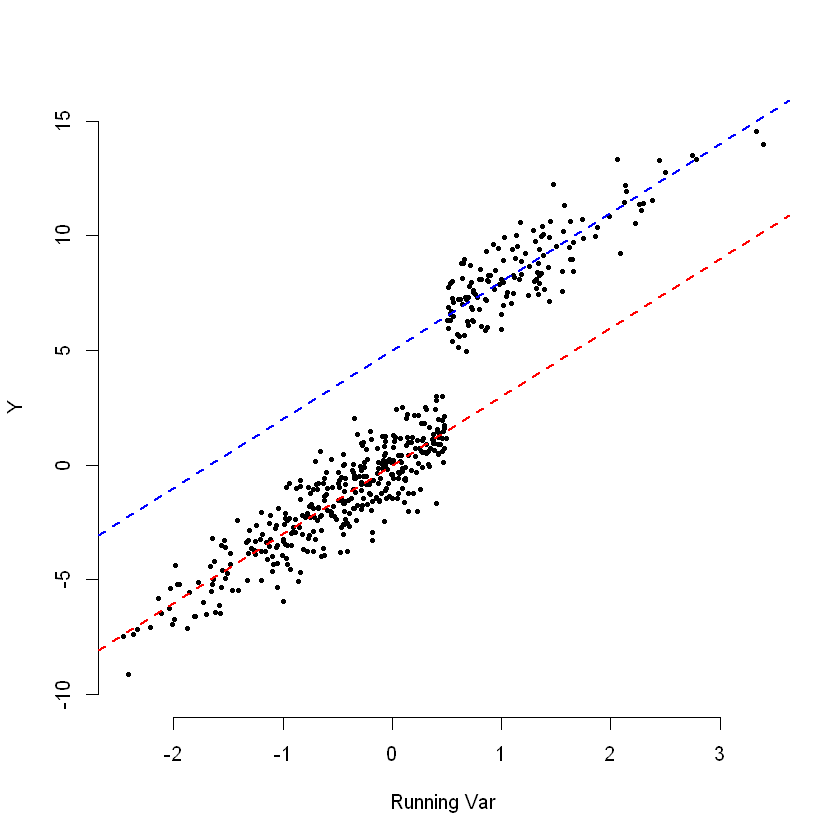

In [9]:
#Simular datos
set.seed(11102025)
x = rnorm(500, 0, 1); D = I(x >= 0.5)
e = rnorm(500, 0, 1)
tau = 5 #Efecto del tratamiento

y1 = 3*x + tau*D + e 
plot(x, y1, ylim = c(-10, 15), pch = 19, cex = 0.6, frame = FALSE, xlab = 'Running Var', ylab = 'Y')
abline(0, 3, col = "red", lty = 2, lwd = 2); abline(tau, 3, col = "blue", lty = 2, lwd = 2) #Esperanza condicional

#### Problemas de Especificación 

Observe que a diferencia de las regresiones que hemos estudiado hasta ahora, $x_i$ no solo es una covariable sino que determina cuales individuos son tratados. La metodología de regresión dicontinua captura el efecto del tratamiento distinguiendo la parte no-lineal y discontinua, $D_i = 1(x_i \geq c)$, de la parte continua, $x_i$.

Sin embargo, es posible que exista una relación no-lineal entre $x_i$ y $y_i$. Es decir, es posible que 

$$y_i(0) = f(x_i)$$

Luego, una alternativa es estimar la ecuación:

$$y_i = f(x_i) + \tau D_i + \varepsilon_i$$

Una forma de aproximar $f(\cdot)$ es a través de un polinomio (global) de grado $k$ . Es decir, se puede estimar:

$$y_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2 + ... + \beta_k x_i^k + \tau D_i + \varepsilon_i$$

[Imbens y Lemieux (2008, JE)](https://doi.org/10.1016/j.jeconom.2007.05.001) sugieren usar polinomios de diferentes grados como una forma de evaluar la sensibilidad de los resultados (es decir, como un ejercicio de robustez). A continuación veremos por qué.

Como señalan Angrist y Pischke (2009), **la validez de las estimaciones** del efecto causal **dependen de** si el **polinomio** usado provee o no una adecuada descripción de $E(y_i(0) | x_i)$. De lo contrario, lo que se interpreta como un salto debido al tratamiento, pordría ser simplemente un factor de confunsión (o sesgo) por especificar mal (u omitir la relación no-lineal) la esperanza condicional del contrafactual.

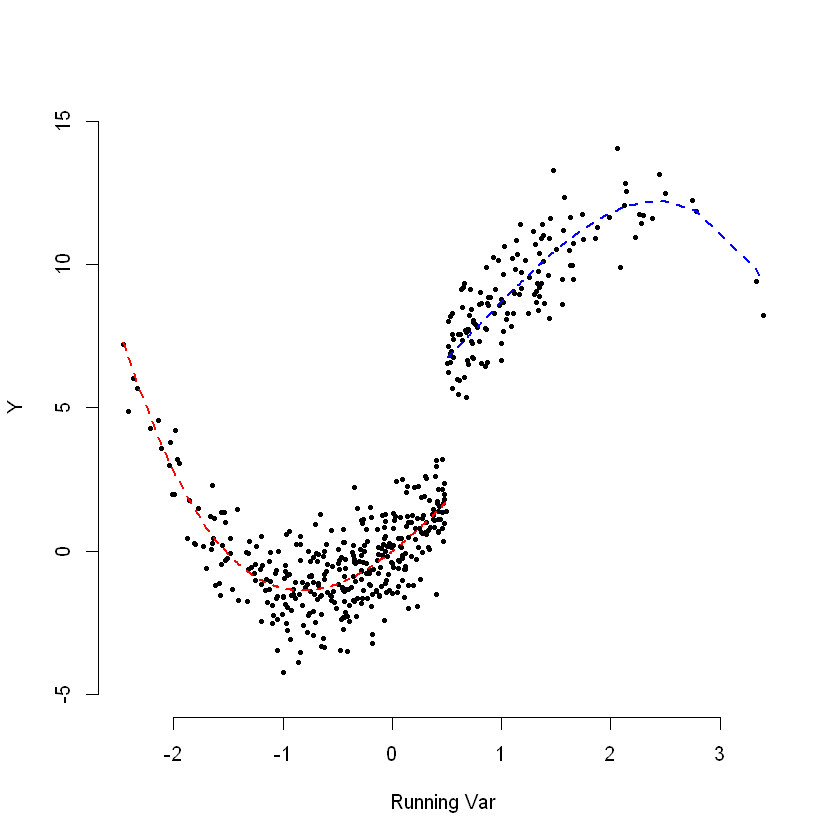

In [10]:
#Relacion no-lineal
y2 = 3*x + 1.2*x^2 - 0.5*x^3 + tau*D + e
x0 = x[x<0.5]; fit0 = 3*x0 + 1.2*x0^2 - 0.5*x0^3
x1 = x[x>=0.5]; fit1 = 3*x1 + 1.2*x1^2 - 0.5*x1^3 + tau 

plot(x, y2, ylim = c(-5, 15), pch = 19, cex = 0.6, frame = FALSE, xlab = 'Running Var', ylab = 'Y')
lines(x0[order(x0)], fit0[order(x0)], col = "red", lty = 2, lwd = 2); lines(x1[order(x1)], fit1[order(x1)], col = "blue", lty = 2, lwd = 2)

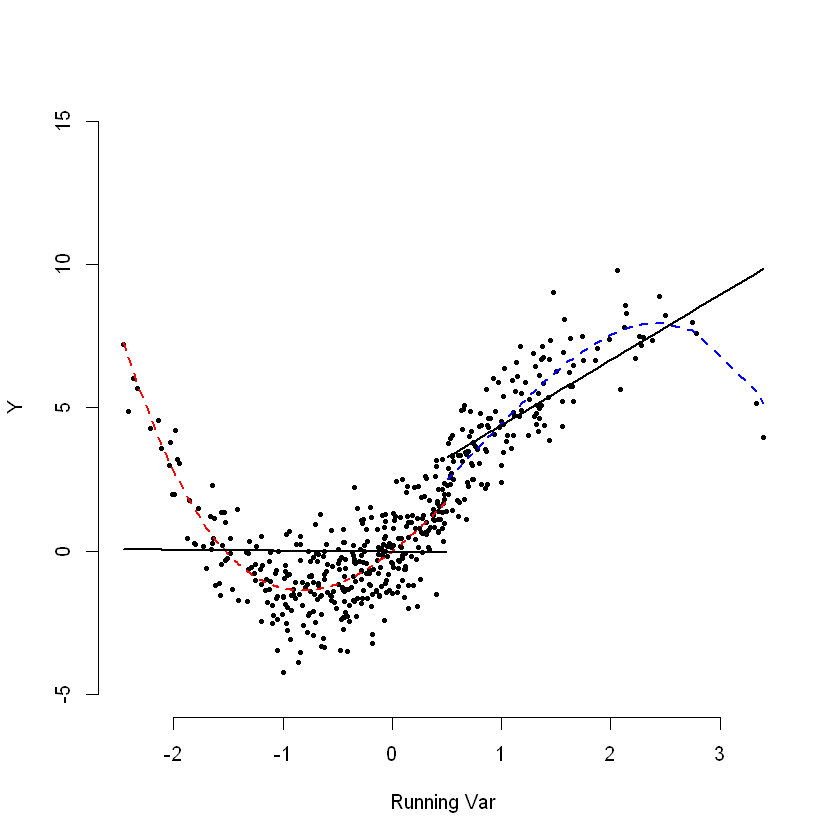

In [11]:
#Relacion no-lineal vs lineal
y3 = 3*x + 1.2*x^2 - 0.5*x^3 + 0.15*tau*D + e
fit0 = 3*x0 + 1.2*x0^2 - 0.5*x0^3; lfit0 = -0.02658 + -0.03562*x0
fit1 = 3*x1 + 1.2*x1^2 - 0.5*x1^3 + 0.15*tau; lfit1 = 2.128 + 2.272*x1 

plot(x, y3, ylim = c(-5, 15), pch = 19, cex = 0.6, frame = FALSE, xlab = 'Running Var', ylab = 'Y')
lines(x0[order(x0)], fit0[order(x0)], col = "red", lty = 2, lwd = 2); lines(x1[order(x1)], fit1[order(x1)], col = "blue", lty = 2, lwd = 2)
lines(x0[order(x0)], lfit0[order(x0)], col = "black", lty = 1, lwd = 2); lines(x1[order(x1)], lfit1[order(x1)], col = "black", lty = 1, lwd = 2)

#### Estimación No Paramétrica

Para reducir la posibilidad de cometer errores, **se considera unicamente los datos de individuos alrededor del punto de corte**, es decir, se define una vecindad $[c - \Delta, c + \Delta]$ donde $\Delta$ es un valor positivo pequeño, conocido como *bandwidth*. De esta manera, 

$$E(y_i | c - \Delta < x_i < c) \approx E(y_i(0) | x_i = c)$$
$$E(y_i | c \leq x_i < c + \Delta) \approx E(y_i(1) | x_i = c)$$

Finalmente, el **estimador no-paramétrico del efecto causal** esta dado por:

\begin{align*}
\tau(c) & = \lim_{\Delta \to 0} E(y_i | c \leq x_i < c + \Delta) - E(y_i | c - \Delta < x_i < c) \\
& = E(y_i(1)- y_i(0) | x_i = c)
\end{align*}

Es importante notar que:

- **estimar la esperanza** de la variable de resultado, $y_i$, **en intervalos pequeños** del running variable **trae inconvenientes**. En particular, el reducido tamaño de muestra genera baja precisión en las estimaciones (i.e., la varianza de las estimaciones es alta). 


- Por otro lado, es necesario seleccionar el parámetro $\Delta$ de forma que minimize el sesgo por alejarse del punto de corte, pero considerando que para valores pequeños de $\Delta$, la varianza de las estimaciones tiende a crecer (*bias-variance trade off*).

Para solucionar estos problemas se usan métodos no-paramétricos. En particular, se estiman regresiones polinomiales locales ([Hahn, Todd, and van der Klaauw, 2001 ECTA](https://onlinelibrary.wiley.com/doi/abs/10.1111/1468-0262.00183)), metodologías para minimizar MSE a partir de **validación cruzada**, y estimadores que corrigen sesgos de cobertura ([Calonico, Cattaneo, y Titiunik, 2014 ECTA](https://doi.org/10.3982/ECTA11757)).

#### Supuestos de Identificación

Antes de realizar cualquier análisis empírico se debe verificar la validez interna de la metodología. Es decir, debemos presentar evidencia de que los diferentes supuestos de identifación del método se cumplen. 

Para el método de regresión discontinua, existen dos supuestos de identificación:

1. **No existe manipulación del puntaje de asignación al tratamiento**. Este supuesto se puede validar estudiando la distribución de la running variable. Si no existen discontinuidades (o *bunching*) en la distribución alrededor del puntaje de corte, se puede concluir que no existe manipulación.


2. **El punto de corte debe ser arbitrario** (o definido de manera aleatoria). Este supuesto se puede validar evaluando si las covariables o características predeterminadas (es decir, la informacion de los individuos previas al tratamiento) son continuas alrededor del punto de corte.

A través de la siguiente aplicación veremos cómo se evalúa la validez de estos supuestos.

### 5.3.2 Aplicación: Retornos a Señalizar Habilidades

[Busso, Montaño, y Muñoz (2025, RESTAT)](https://doi.org/10.1162/REST.a.1635) estudian el efecto de obtener la distinción del mejor Saber Pro en los salarios de los egresados de educación superior. 

Los autores estiman la siguiente ecuación:

$$\log(Earnings_{ijt}) = \alpha + \beta Z_{ijt} + \tau D_{ijt} + \delta (Z_{ijt} \times D_{ijt}) + X_i'\gamma + \varepsilon_{ijt}$$

Donde:

- $\log(Earnings_{ijt})$ es el logarítmo natural del primer salario percibido por el individuo $i$ después de graduarse del programa $j$
- $Z_{ijt} = Puntaje_{i} - c_{jt}$ es el puntaje centrado alrededor del valor mínimo para obtener la distinción del mejor Saber Pro en el programa $j$ en el año $t$
- $D_{ijt} = 1(Puntaje_{i} > c_{jt})$ es una variable binaria que indica si el individuo $i$ recibió la distinción del mejor Saber Pro
- $X_i$ es un conjunto de características del individuo, las cuales se observan previo a recibir la distinción (es decir, Saber 11, género, edad, tipo de universidad, etc)


#### Validez Interna

**1. Evidencia de No Manipulación**:

Las siguientes gráficas presentan evidencia de que alrededor del punto de corte no existe **bunching** (o discontinuidad) en la distribución del running variable. 

<img src="images/NormalizedDensity.png" align="center" alt="drawing" width="350"/><img src="images/ManipulationTest.png" align="center" alt="drawing" width="350"/>

**2. Evidencia Cuasi-aleatoridad**:

Las siguentes figuras presentan evidencia de que alrededor del puntaje de corte **no hay discontinuidades en características pre-determinadas**.

<img src="images/RDfemale.png" alt="Figure 1" width="350"><img src="images/RDworking.png" alt="Figure 2" width="350">

<img src="images/RDsb11score.png" alt="Figure 1" width="350"><img src="images/RDenglish.png" alt="Figure 2" width="350">

#### Resultados

La siguiente tabla presenta estimaciones, a partir del método de regresión discontinua, para el efecto de recibir la distinción del mejor Saber Pro.

<img src="images/Tabla1.png" alt="Table1" width="550">

### 5.3.3 Aplicación: Manipulación del Tratamiento

[Camacho y Conover (2011, AEJ: Policy)](https://www.aeaweb.org/articles?id=10.1257/pol.3.2.41) documentan la evolución a través del tiempo del puntaje del Sisben, el cual es usado para asignar familias a diferentes programas de política social y salud en Colombia. Los autores documentan manipulación de los resultados, lo cual podría explicarse por razones políticas para influir en elecciones y a publicar el algorítmo de calificación en 1997. 

<img src="images/Sisben94.png" alt="Figure 1" width="400"><img src="images/Sisben97.png" alt="Figure 2" width="400">

<img src="images/Sisben98.png" alt="Figure 1" width="400"><img src="images/Sisben03.png" alt="Figure 2" width="400">

### 5.3.4 Regresión Discontinua Borrosa

Observe que en regresión discontinua nítida, $P(D_i = 1 | x_i \geq c) = 1$ y $P(D_i = 1 | x_i < c) = 0$. Es decir, todos los individuos elegibles para ser tratados son efectivamente tratados y los no elegibles no reciben tratamiento. 

Sin embargo, lo anterior no ocurre en todos las aplicaciones. Esto es así porque algunos individuos elegibles a recibir tratamiento deciden no formar parte del tratamiento. Más aún, es posible que individuos no elegibles logren recibir tratamiento. El método de **regresión discontinua borrosa** estima el efecto del tratamiento controlando por la falta de cumplimiento (*lack of compliance*) de la regla de asignación. En particular, se explota el hecho de que


\begin{equation*}
Pr(D_i = 1 | x_i) =
    \left\{\begin{array}{lr}
    g_1(x_i) & \text{ si } x_i \geq c \\
    g_0(x_i) & \text{ si } x_i < c
    \end{array}\right.
    \quad \text{ donde }\hspace{5pt} g_1(c) \neq g_0(c)
\end{equation*}

Sin perdida de generalidad, asumimos que $g_1(c) > g_0(c)$, es decir, que la probabilidad de recibir tratamiento aumenta cuando $x_i \geq c$.

La relación entre la probabilidad de recibir tratamiento y $x_i$ se puede escribir como:

$$E(D_i | x_i) = Pr(D_i = 1 | x_i) = g_0(x_i) + (g_1(x_i) - g_0(x_i)) \cdot T_i$$

donde 

$$T_i = 1(x_i \geq c)$$

Es decir, $T_i$ es una variable binaria que indica el punto en el que la esperanza condicional $E(D_i | x_i)$ salta de manera discontinua.

Para estimar el efecto del tratamiento $D_i$ (LATE) sobre la variable de resultado $y_i$, procedemos en dos etapas:

1. Estimamos $E(D_i | x_i)$ a partir de la ecuación:
 
$$D_i = \gamma_0 + \gamma_1 x_i + ... + \gamma_k x^k_i + \pi T_i + \xi_i$$

2. Estimamos el efecto del tratamiento considerando que la probabilidad de ser tratado salta de manera discontinua:
  
$$y_i = f(x_i) + \tau \hat D_i + \varepsilon_i$$

Finalmente, el estimador de regresión discontinua está dado por

$$\tau(c) = E(\tau | D_i = 1, x_i \geq c) = \frac{\lim_{x \downarrow c} E(y_i | x_i = x) - \lim_{x \uparrow c} E(y_i | x_i = x)}{\lim_{x \downarrow c} Pr(D_i = 1 | x_i = x) - \lim_{x \uparrow c} Pr(D_i = 1 | x_i = x) }$$

Observe que para estimar el efecto de intención de tratamiento (ITT) usamos la siguiente ecuación de forma-reducida:

$$y_i = m(x_i) + \rho T_i + \varepsilon_i = \gamma_0 + \gamma_1 x_i + \gamma_2 x^2_i + ... + \gamma_k x^k_i + \rho T_i + u_i$$

donde 

$$\rho = \pi \cdot \tau \quad \Rightarrow \quad \tau = \frac{\rho}{\pi}$$

La forma reducia es informativa en muchos casos. Pero de manera importante, **la forma reducida nos permite presentar evidencia gráfica de la discontinuidad en la variable de resultado al rededor del punto corte**. 

Es usual que el analísta presente la evidencia gráfica, mida el impacto usando la forma reducida, y posteriormente estime el efecto promedio local.

### 5.3.5 Aplicación: Ser Pilo Paga

[Londoño, Rodríguez, y Sánchez (2020, AEJ: Policy)](https://www.aeaweb.org/articles?id=10.1257/pol.20180131) y [Londoño, Rodríguez, Sánchez, y Álvarez (2025, JPE)](https://www.nber.org/papers/w31737) estudian el efecto de ser beneficiario del programa Ser Pilo Paga sobre multiples variables de resultado. En particular, el documento estima efectos sobre:

1. Probabilidad de matricularse en educación superior,
2. Tipo de institución donde se matriculan los estudiantes
3. Probabilidad de graduarse
4. Probabilidad de tener empleo formal y salario

Los autores encuentran que los estudiantes beneficiarios tienen mayor probabilidad de matricularse en un programa de educación superior. De manera, especifica, la probabilidad de matricularse aumenta entre 56% y 86%. 

Adicionalmente, los autores proveen evidencia de que la probabilidad de matricularse en una institución de alta calidad aumentó para los beneficiarios, mientras su probabilidad de matricularse en instituciones de baja calidad se redujo. La graduación aumentó en 66.5% (o 26.8 p.p.)

## 5.4 Diferencias en Diferencias

El modelo de diferencias en diferencias (DiD) es una herramienta útil para estimar el efecto causal de políticas que focalizan un grupo de individuos. Bajo ciertos supuestos, este método logra eliminar diferencias pre-existentes entre el grupo focalizado y otros grupos poblacionales (*control o contrafactual*), y con ello determinar el impacto de una política.

Para usar este método se requiren datos longitudinales o cortes transversales repetidos en los cuales es posible identificar los individuos afectados (*directa o indirectamente*) por la política.

### 5.4.1 Comparación entre Grupos

El modelo de **diferencias en diferencias combina dos métodos** simples para estimar el efecto causal de la política, $\tau$:

- *Comparar los resultados del grupo de tratados y los resultados del grupo de control en un periodo de tiempo particular*. Para implementar esta idea, podemos usar el siguiente estimador:
   
   $$\hat\tau^* = \bar y_{t}(1) - \bar y_t(0)$$
   
   *Problema*: Esta idea asume que no existen diferencias (pre-existentes) entre el grupo de tratamiento y el grupo de control.
   
   
- *Comparar los resultados del grupo tratados antes y después de recibir el tratamiento*. Para implementar esta idea, podemos usar el siguiente estimador:

   $$\hat\tau^{\bullet} = \bar y_{t}(1) - \bar y_{t-1}(1)$$

   *Problema*: Esta idea asume que factores diferentes al tratamiento no afectan la variable de resultado a traves del tiempo.

### 5.4.2 Intuición del Método

Supongamos que **en un periodo $t$ se introdujo de manera exogena un cambio de política** (es decir, un tratamiento) que afectó de manera directa a un grupo de individuos, a quienes podemos identificar con una variable binaria $D_{i}$.

El estimador de diferencias en diferencias se puede calcular a partir de los promedios de la variable de resultado para el grupo de tratados y el grupo de control, antes y después de la introducción del tratamiento.

De manera específica, el estimador de diferencias en diferencias está dado por:

$$\hat\tau^{DiD} = [\bar y_{t}(1) - \bar y_{t-1}(1)] - [\bar y_{t}(0) - \bar y_{t-1}(0)]$$

Observe que esta expresión es equivalente a estimar:

$$\hat\tau^{DiD} = [\bar y_{t}(1) - \bar y_{t}(0)] - [\bar y_{t-1}(1) - \bar y_{t-1}(0)]$$

Esta última ecuación permite **interpretar** el estimador de diferencias en diferencias como **la brecha que persiste entre los grupos de tratamiento y control cuando se controla por las diferencias pre-existentes entre ambos grupos**.

<img src="images/DiD_fig.png" width="500">

### 5.4.3 Tendencias Paralelas

La figura anterior es una representación gráfica del estimador de diferencias en diferencias. Es importante notar dos elementos a partir de esta figura: 

1. Existen diferencias pre-tratamiento entre los grupos de tratamiento y control

2. La intervención cambia la tendencia (o comportamiento) de la variable de resultado para el grupo de tratamiento, pero no la cambia para el grupo de control.

Para interpretar el estimador de diferencias en diferencias como un parámetro causal, es necesario suponer que la tendencia de la variable dependente, en ausencia del tratamiento, es igual para los grupos de tratamiento y control (**tendencias paralellas**).

### 5.4.4 Aplicación: Salario Mínimo y Empleo

[Card y Krueger (1994)](https://davidcard.berkeley.edu/papers/njmin-aer.pdf) evalúan el impacto del incremento del salario mínimo en Nueva Jersey en 1992 utilizando un diseño de diferencias en diferencias. Los autores comparan cambios en empleo en restaurantes de comida rápida en Nueva Jersey (tratamiento) con los de Pensilvania (control), donde el salario mínimo no cambió.

A través de encuestas directas a los establecimientos, los autores encuentran que el aumento del salario mínimo no redujo el empleo; de hecho, reportan un leve incremento en el empleo en Nueva Jersey en comparación con Pensilvania. Esto contradijo la predicción estándar del modelo competitivo de que un salario mínimo reduce el empleo.

El estudio contribuyó de manera crucial a la literatura al mostrar evidencia empírica que apoya modelos alternativos de mercado laboral, como la competencia monopsonística, y reabrió el debate sobre los efectos del salario mínimo.

### 5.4.5 Modelo de Regresión

El estimador diferencias en diferencias se puede obtener a partir del siguiente modelo de regresión:

$$y_{it} = \beta_0 + \beta_1 Post_{t} + \beta_2 D_i + \beta_3 Post_{t} \times D_i + \varepsilon_{it}$$

Donde 

\begin{equation*}
D_i =
    \left\{\begin{array}{lr}
    1, & \text{si } i \text{ es tratado} \\
    0, & \text{otro caso}
    \end{array}\right.
\qquad Post_t =
    \left\{\begin{array}{lr}
    1, & \text{si } t \text{ es el periodo post-tratamiento} \\
    0, & \text{otro caso}
    \end{array}\right.
\end{equation*}

Obseve que 

$$\beta_3 = \underbrace{\Bigl[E(y_{it} | Post_t = 1 , D_i = 1) -  E(y_{it} | Post_t = 1 , D_i = 0)\Bigr]}_{(\beta_0 + \beta_1 + \beta_2 + \beta_3) \hspace{5pt}-\hspace{5pt} (\beta_0 + \beta_1)} - \underbrace{\Bigl[E(y_{it} | Post_t = 0 , D_i = 1) -  E(y_{it} | Post_t = 0 , D_i = 0)\Bigr]}_{(\beta_0 + \beta_2) \hspace{5pt}-\hspace{5pt} \beta_0}$$

### 5.4.6 Estimación 

El método de mínimos cuadrados ordinarios nos permite estimar el modelo de diferencias en diferencias. 

Observe que una ventaja de usar el modelo de regresión es que podemos **controlar por factores que cambian a través del tiempo**, $X_{it}$, y que se relacionan con la variable de resultado. En dicho caso, el modelo se puede reescribir como:

$$y_{it} = \beta_0 + \beta_1 Post_{t} + \beta_2 D_i + \beta_3 Post_{t} \times D_i + {\color{red} X_{it}'\delta} + \varepsilon_{it}$$

Incluir información adicional en el modelo aumenta la precisión de las estimaciones puntuales.

En el caso en que tenemos datos longitudinales y contamos con múltiples periodos, podemos **incluir efectos fijos de individuo (o grupo) y de tiempo**: 

$$y_{it} = \beta_0 + \beta_1 Post_{t} + \beta_2 D_i + \beta_3 Post_{t} \times D_i + X_{it}'\delta + {\color{red} \mu_i + \mu_t} + \varepsilon_{it}$$

Recordemos que $\mu_i$ controla por características del individuo que no cambian a través del tiempo (bien sea observadas o no observadas) y $\mu_t$ controla por cambios de política o factores que afectan a todos los individuos a lo largo del tiempo.

Esta última expresion se puede estimar usando los diferentes modelos de datos panel que estudiamos previamente (i.e., primeras diferencias, modelo within, y modelo con variables binarias o dummy). 